<a href="https://colab.research.google.com/github/daniel64bit/distribuicao-renovavel/blob/dev/notebooks/entregas/entrega_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2024/02**


# **Entrega 3**

---

# **Título do Projeto**
---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Aluno 1, 123456789' #@param {type:"string"}
Aluno2 = 'Aluno 2, 123456789' #@param {type:"string"}
Aluno3 = 'Aluno 3, 123456789' #@param {type:"string"}
Aluno4 = 'Aluno 4, 123456789' #@param {type:"string"}
Aluno5 = 'Aluno 5, 123456789' #@param {type:"string"}





# **Introdução**

Juntar os tópicos de contexto, motivação, objetivo geral, objetivos específicos (incluir a bases de dados que será explorada) e justificativa em um único tópico.

# **Referencial Teórico**

(1 página) Defir resumidamente os principais conceitos envolvidos na sua solução. Discutir os trabalhos correlacionados. Apresentar alternativas de solução que foram empregadas no mesmo problema ou problemas semelhantes, e suas vantagens e limitações. Indicar referências ao longo do texto (padrão ABNT).



# **Diagrama de Solução**

Apresente e discuta o diagrama da solução proposta. Utilize o pipeline proposto inicialmente como base.

# **EDA e Pré-processamento dos dados**

Exploração e análise dos dados. Discussão e análise dos dados empregados (qualidade, limitações, simplicações ou recortes adotados etc.). Tarefas de preparação dos dados (transformações, compactação e encodes, junções de dados etc.).

## 1. **ANEEL**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# Importação dos dados

df_dadoscomerciais = pd.read_csv('indger-dados-comerciais.csv', sep=";", encoding='latin1')
df_municipios = pd.read_excel('RELATORIO_DTB_BRASIL_MUNICIPIO.xlsx')

In [15]:
# Análise inicial da base de dados da ANEEL

df_dadoscomerciais.head()

,DatGeracaoConjuntoDados,NumCNPJ,SigAgente,NomAgente,NomTipoOutorga,DatReferenciaInformada,CodMunicipioIBGE,QtdUCAtiva,QtdUCAtivaFat,QtdFatura,...,QtdInspecVerifProcIrregular,QtdTermosOcorrInspecao,QtdTermosOcorrInspecaoCobr,QtdTermosOcorrInspecaoEncerr,QtdProceCobrDefMedidor,QtdReligCobr,QtdUCSuspInadimplemento,QtdSuspIndev,VlrTotCompSuspIndevida,DthCarga
0,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-02-01,4202800,239,239,239,...,0,0,0,0,0,0,0,0,",000000000",2024-08-04 04:01:22.983000000
1,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4214904,108,108,108,...,0,0,0,0,0,0,0,0,",000000000",2024-08-04 04:01:22.983000000
2,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4206108,3642,3630,3634,...,0,0,0,0,0,0,21,21,",000000000",2024-08-04 04:01:22.983000000
3,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4202800,239,239,239,...,0,0,0,0,0,0,0,0,",000000000",2024-08-04 04:01:22.983000000
4,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2023-12-01,4214904,108,108,109,...,0,0,0,0,0,0,0,0,",000000000",2024-08-04 04:01:22.983000000


In [16]:
pd.set_option('display.max_rows', None)

print(f"""Tipo de dados:
{df_dadoscomerciais.dtypes}

Colunas:
{df_dadoscomerciais.columns}

Formato:
{df_dadoscomerciais.shape[0]} Linhas e {df_dadoscomerciais.shape[0]} Colunas

Nulos:
{df_dadoscomerciais.isnull().sum()}
""")

Tipo de dados:
DatGeracaoConjuntoDados          object
NumCNPJ                           int64
SigAgente                        object
NomAgente                        object
NomTipoOutorga                   object
DatReferenciaInformada           object
CodMunicipioIBGE                  int64
QtdUCAtiva                        int64
QtdUCAtivaFat                     int64
QtdFatura                         int64
QtdFaturaSemLeitura               int64
QtdFaturaSemLeituraImpAcesso      int64
QtdFaturaSemLeituraEmergencia     int64
QtdFaturaSemLeituraPlurimensa     int64
QtdFaturaSemLeituraFatEstimad     int64
QtdFaturaSemLeituraFimContrat     int64
QtdFaturaSemLeituraAusenciaTm     int64
QtdRefaturamento                  int64
QtdFaturaAcerto                   int64
QtdFaturaAcertoFatIncorreto       int64
QtdFaturaAcertoFatIncorDevDob     int64
QtdFaturaAcertoFatIncorDevSEC     int64
QtdFaturaAcertoFatIncorDevSET     int64
QtdFaturaAcertoFatImpAcesso       int64
QtdFaturaAcertoFatEmergen

In [17]:
# Corrigindo os tipos de dado.

pd.reset_option('display.max_rows')


string_cols = ['SigAgente', 'NomAgente', 'NomTipoOutorga']
float_cols = ['VlrRestAnte', 'VlrRestAtrasado', 'VlrRestPendente', 'VlrRestPendenteAtrasado','VlrPendentePgtRessarcDanoDefe',
              'VlrPagoRessarcDano', 'MdaTempoMedAtendimentoPosto', 'MdaTempoMedAtendPostoDiaFort', 'VlrTotCompSuspIndevida']
dt_cols = ['DatGeracaoConjuntoDados', 'DatReferenciaInformada', 'DthCarga']

df_dadoscomerciais[float_cols] = df_dadoscomerciais[float_cols].replace({",":"."}, regex=True)

df_dadoscomerciais[string_cols] = df_dadoscomerciais[string_cols].astype(str)
df_dadoscomerciais[float_cols] = df_dadoscomerciais[float_cols].astype(float)
df_dadoscomerciais[dt_cols] = df_dadoscomerciais[dt_cols].apply(pd.to_datetime)

In [18]:
# Análise inicial da base de dados do IBGE.


df_municipios.head()

,UF,Nome_UF,Região Geográfica Intermediária,Nome Região Geográfica Intermediária,Região Geográfica Imediata,Nome Região Geográfica Imediata,Mesorregião Geográfica,Nome_Mesorregião,Microrregião Geográfica,Nome_Microrregião,Município,Código Município Completo,Nome_Município
0,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,2,Leste Rondoniense,6,Cacoal,15,1100015,Alta Floresta D'Oeste
1,11,Rondônia,1102,Ji-Paraná,110005,Cacoal,2,Leste Rondoniense,6,Cacoal,379,1100379,Alto Alegre dos Parecis
2,11,Rondônia,1101,Porto Velho,110002,Ariquemes,2,Leste Rondoniense,3,Ariquemes,403,1100403,Alto Paraíso
3,11,Rondônia,1102,Ji-Paraná,110004,Ji-Paraná,2,Leste Rondoniense,5,Alvorada D'Oeste,346,1100346,Alvorada D'Oeste
4,11,Rondônia,1101,Porto Velho,110002,Ariquemes,2,Leste Rondoniense,3,Ariquemes,23,1100023,Ariquemes


In [19]:
municipios_cols = ['UF', 'Nome_UF', 'Município', 'Código Município Completo', 'Nome_Município']
df_municipios_filter = df_municipios[municipios_cols]
print(f"""Tipo de dados:
{df_municipios_filter.dtypes}

Colunas:
{df_municipios_filter.columns}

Formato:
{df_municipios_filter.shape[0]} Linhas e {df_municipios_filter.shape[0]} Colunas

Nulos:
{df_municipios_filter.isnull().sum()}

""")

Tipo de dados:
UF                            int64
Nome_UF                      object
Município                     int64
Código Município Completo     int64
Nome_Município               object
dtype: object

Colunas:
Index(['UF', 'Nome_UF', 'Município', 'Código Município Completo',
       'Nome_Município'],
      dtype='object')

Formato:
5570 Linhas e 5570 Colunas

Nulos:
UF                           0
Nome_UF                      0
Município                    0
Código Município Completo    0
Nome_Município               0
dtype: int64




In [20]:
# Corrigindo os tipos dos dados

municipios_str_cols = ['Nome_UF', 'Nome_Município']
df_municipios_filter.loc[:, municipios_str_cols] = df_municipios_filter[municipios_str_cols].astype(str)

In [21]:
#Realizando o cruzamento das tabelas para obter as informações dos municípios.

df_dadoscomerciais_merge = df_dadoscomerciais.merge(df_municipios_filter,
                                                    how = 'left',
                                                    left_on = 'CodMunicipioIBGE',
                                                    right_on ='Código Município Completo',
                                                    )

df_dadoscomerciais_merge

,DatGeracaoConjuntoDados,NumCNPJ,SigAgente,NomAgente,NomTipoOutorga,DatReferenciaInformada,CodMunicipioIBGE,QtdUCAtiva,QtdUCAtivaFat,QtdFatura,...,QtdReligCobr,QtdUCSuspInadimplemento,QtdSuspIndev,VlrTotCompSuspIndevida,DthCarga,UF,Nome_UF,Município,Código Município Completo,Nome_Município
0,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-02-01,4202800,239,239,239,...,0,0,0,0.0,2024-08-04 04:01:22.983,42,Santa Catarina,2800,4202800,Braço do Norte
1,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4214904,108,108,108,...,0,0,0,0.0,2024-08-04 04:01:22.983,42,Santa Catarina,14904,4214904,Rio Fortuna
2,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4206108,3642,3630,3634,...,0,21,21,0.0,2024-08-04 04:01:22.983,42,Santa Catarina,6108,4206108,Grão-Pará
3,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2024-01-01,4202800,239,239,239,...,0,0,0,0.0,2024-08-04 04:01:22.983,42,Santa Catarina,2800,4202800,Braço do Norte
4,2024-08-05,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,Permissão,2023-12-01,4214904,108,108,109,...,0,0,0,0.0,2024-08-04 04:01:22.983,42,Santa Catarina,14904,4214904,Rio Fortuna
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110126,2024-08-05,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,Permissão,2023-08-01,4321808,1961,1956,1957,...,3,9,9,0.0,2024-08-04 04:01:22.613,43,Rio Grande do Sul,21808,4321808,Três de Maio
110127,2024-08-05,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,Permissão,2023-08-01,4319737,1,1,1,...,0,0,0,0.0,2024-08-04 04:01:22.613,43,Rio Grande do Sul,19737,4319737,São Valério do Sul
110128,2024-08-05,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,Permissão,2023-08-01,4319109,42,41,41,...,0,1,1,0.0,2024-08-04 04:01:22.613,43,Rio Grande do Sul,19109,4319109,São Martinho
110129,2024-08-05,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,Permissão,2023-08-01,4318499,165,164,164,...,0,0,0,0.0,2024-08-04 04:01:22.613,43,Rio Grande do Sul,18499,4318499,São José do Inhacorá


In [22]:
# Aqui estamos realizando um filtro para manter somente as colunas relevantes para nossa análise.

df_dadoscomerciais_merge_final = df_dadoscomerciais_merge[['NumCNPJ',
                                                            'SigAgente',
                                                            'NomAgente',
                                                            'DatReferenciaInformada',
                                                            'CodMunicipioIBGE',
                                                            'UF',
                                                            'Nome_UF',
                                                            'Nome_Município',
                                                            ]]
df_dadoscomerciais_merge_final

,NumCNPJ,SigAgente,NomAgente,DatReferenciaInformada,CodMunicipioIBGE,UF,Nome_UF,Nome_Município
0,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,2024-02-01,4202800,42,Santa Catarina,Braço do Norte
1,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,2024-01-01,4214904,42,Santa Catarina,Rio Fortuna
2,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,2024-01-01,4206108,42,Santa Catarina,Grão-Pará
3,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,2024-01-01,4202800,42,Santa Catarina,Braço do Norte
4,1229747000189,Cergapa,COOPERATIVA DE ELETRICIDADE DE GRÃO PARÁ,2023-12-01,4214904,42,Santa Catarina,Rio Fortuna
...,...,...,...,...,...,...,...,...
110126,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,2023-08-01,4321808,43,Rio Grande do Sul,Três de Maio
110127,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,2023-08-01,4319737,43,Rio Grande do Sul,São Valério do Sul
110128,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,2023-08-01,4319109,43,Rio Grande do Sul,São Martinho
110129,98042963000152,Certhil,COOPERATIVA DE DISTRIBUIÇÃO DE ENERGIA ENTRE R...,2023-08-01,4318499,43,Rio Grande do Sul,São José do Inhacorá


In [23]:
# Realizando uma agregação para por UF e Concessionária para uma sumarização.

df_concessionarias_por_uf = df_dadoscomerciais_merge_final.groupby(['Nome_UF', 'UF', 'SigAgente', 'NumCNPJ']).agg(UltimoRegistro=('DatReferenciaInformada', 'max')).reset_index()
df_concessionarias_por_uf.head()


,Nome_UF,UF,SigAgente,NumCNPJ,UltimoRegistro
0,Acre,12,Energisa AC,4065033000170,2024-06-01
1,Alagoas,27,Equatorial AL,12272084000100,2024-06-01
2,Alagoas,27,Neoenergia Coelba,15139629000194,2024-06-01
3,Alagoas,27,Neoenergia Pernambuco,10835932000108,2024-06-01
4,Amapá,16,CEA Equatorial,5965546000109,2024-06-01


In [24]:
# Realizando uma transformação para validar a última data de atuação de cada concessionária em cada estado.
# Adicionando uma nova coluna que contém a contagem do número de concessionárias por estado.

df_concessionarias_por_uf["DataMax"] = df_concessionarias_por_uf.groupby("SigAgente")["UltimoRegistro"].transform("max")
df_concessionarias_por_uf = df_concessionarias_por_uf[
    df_concessionarias_por_uf["UltimoRegistro"] == df_concessionarias_por_uf["DataMax"]
]
df_concessionarias_por_uf["Quantidade_Concessionárias_UF"] = df_concessionarias_por_uf.groupby("Nome_UF")["SigAgente"].transform("count")


In [25]:
# Removendo a coluna redundante.

df_concessionarias_por_uf = df_concessionarias_por_uf.drop("DataMax", axis=1)
df_concessionarias_por_uf.head()

,Nome_UF,UF,SigAgente,NumCNPJ,UltimoRegistro,Quantidade_Concessionárias_UF
0,Acre,12,Energisa AC,4065033000170,2024-06-01,1
1,Alagoas,27,Equatorial AL,12272084000100,2024-06-01,3
2,Alagoas,27,Neoenergia Coelba,15139629000194,2024-06-01,3
3,Alagoas,27,Neoenergia Pernambuco,10835932000108,2024-06-01,3
4,Amapá,16,CEA Equatorial,5965546000109,2024-06-01,1


In [26]:
# Realizando uma agregação para por Município e Concessionária para uma sumarização.


df_concessionarias_por_municipio = df_dadoscomerciais_merge_final.groupby(['Nome_Município', 'SigAgente', 'NumCNPJ']).agg(UltimoRegistro=('DatReferenciaInformada', 'max')).reset_index()


In [27]:
# Realizando uma transformação para validação sobre a última data de atuação da Concessionária em cada município.


df_concessionarias_por_municipio["DataMax"] = df_concessionarias_por_municipio.groupby("SigAgente")["UltimoRegistro"].transform("max")
df_concessionarias_por_municipio = df_concessionarias_por_municipio[
    df_concessionarias_por_municipio["UltimoRegistro"] == df_concessionarias_por_municipio["DataMax"]
]
df_concessionarias_por_municipio["Quantidade_Concessionárias_Município"] = df_concessionarias_por_municipio.groupby("Nome_Município")["SigAgente"].transform("count")



In [28]:
# Removendo a coluna redundante.

df_concessionarias_por_municipio = df_concessionarias_por_municipio.drop("DataMax", axis=1)
df_concessionarias_por_municipio.head()

,Nome_Município,SigAgente,NumCNPJ,UltimoRegistro,Quantidade_Concessionárias_Município
0,Abadia de Goiás,Enel GO,1543032000104,2024-06-01,1
1,Abadia dos Dourados,Cemig-D,6981180000116,2024-06-01,1
2,Abadiânia,Enel GO,1543032000104,2024-06-01,1
3,Abaetetuba,Equatorial PA,4895728000180,2024-06-01,1
4,Abaeté,Cemig-D,6981180000116,2024-06-01,1


(0.0, 30.0)

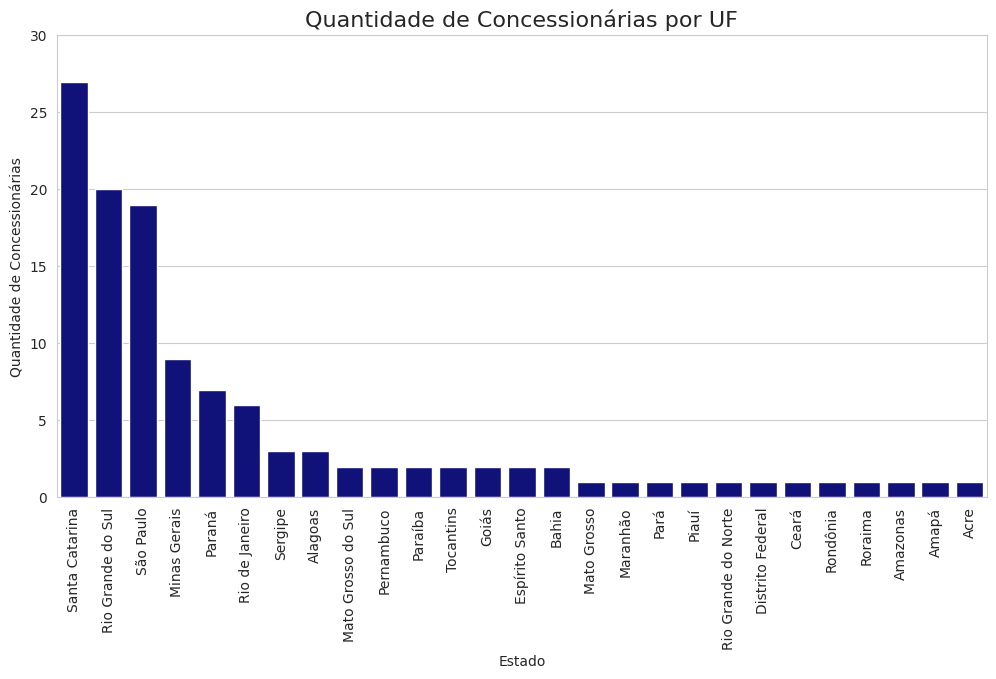

In [29]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.barplot(data=df_concessionarias_por_uf,
              x="Nome_UF",
              y="Quantidade_Concessionárias_UF",
              color="Darkblue",
              order = df_concessionarias_por_uf['Nome_UF'].value_counts().index

)
plt.title("Quantidade de Concessionárias por UF", fontsize = 16)
plt.xlabel("Estado")
plt.ylabel("Quantidade de Concessionárias")
plt.xticks(rotation=90);
plt.ylim(0,30)


In [30]:
# Quantidade de Concessionárias por estado em forma de tabela.

sumarizacao_uf = (df_concessionarias_por_uf[["Nome_UF", "Quantidade_Concessionárias_UF"]]
        .drop_duplicates().
        sort_values(by="Quantidade_Concessionárias_UF", ascending=False)
        .reset_index(drop=True))
sumarizacao_uf

,Nome_UF,Quantidade_Concessionárias_UF
0,Santa Catarina,27
1,Rio Grande do Sul,20
2,São Paulo,19
3,Minas Gerais,9
4,Paraná,7
5,Rio de Janeiro,6
6,Sergipe,3
7,Alagoas,3
8,Mato Grosso do Sul,2
9,Pernambuco,2


In [31]:
# Dados estatísticos sobre as informações obtidas.

sumarizacao_uf.describe()


,Quantidade_Concessionárias_UF
count,27.000000
mean,4.444444
std,6.738713
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,27.000000


In [35]:
from google.colab import files

# Salve os arquivos localmente
df_concessionarias_por_uf.to_csv('df_concessionarias_por_uf.csv', index=False)
df_concessionarias_por_municipio.to_csv('df_concessionarias_por_municipio.csv', index=False)

# Baixe os arquivos
files.download('df_concessionarias_por_uf.csv')
files.download('df_concessionarias_por_municipio.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. **ONS**

In [36]:
df_capacidade_geracao = pd.read_parquet('capacidade_geracao.parquet')

In [37]:
df_capacidade_geracao.head()

,id_subsistema,nom_subsistema,id_estado,nom_estado,nom_modalidadeoperacao,nom_agenteproprietario,nom_tipousina,nom_usina,ceg,nom_unidadegeradora,cod_equipamento,num_unidadegeradora,nom_combustivel,dat_entradateste,dat_entradaoperacao,dat_desativacao,val_potenciaefetiva
0,NE,NORDESTE,AL,ALAGOAS,TIPO I,CHESF,HIDROELÉTRICA,XINGÓ,UHE.PH.SE.027053-9.01,UG 527 MW USINA XINGO 6 AL,ALUXG-0UG6,6,HIDRÁULICA,1994-04-30,1994-04-30,,527.0
1,NE,NORDESTE,AL,ALAGOAS,TIPO I,CHESF,HIDROELÉTRICA,XINGÓ,UHE.PH.SE.027053-9.01,UG 527 MW USINA XINGO 5 AL,ALUXG-0UG5,5,HIDRÁULICA,1995-01-31,1995-01-31,,527.0
2,NE,NORDESTE,AL,ALAGOAS,TIPO I,CHESF,HIDROELÉTRICA,XINGÓ,UHE.PH.SE.027053-9.01,UG 527 MW USINA XINGO 4 AL,ALUXG-0UG4,4,HIDRÁULICA,1995-10-26,1995-10-26,,527.0
3,NE,NORDESTE,AL,ALAGOAS,TIPO I,CHESF,HIDROELÉTRICA,XINGÓ,UHE.PH.SE.027053-9.01,UG 527 MW USINA XINGO 3 AL,ALUXG-0UG3,3,HIDRÁULICA,1996-07-31,1996-07-31,,527.0
4,NE,NORDESTE,AL,ALAGOAS,TIPO I,CHESF,HIDROELÉTRICA,XINGÓ,UHE.PH.SE.027053-9.01,UG 527 MW USINA XINGO 2 AL,ALUXG-0UG2,2,HIDRÁULICA,1996-12-20,1996-12-20,,527.0


In [38]:
print(f"""Tipo de dados:
{df_capacidade_geracao.dtypes}

Colunas:
{df_capacidade_geracao.columns}

Formato:
{df_capacidade_geracao.shape}

Nulos:
{df_capacidade_geracao.isnull().sum()}
""")

Tipo de dados:
id_subsistema              object
nom_subsistema             object
id_estado                  object
nom_estado                 object
nom_modalidadeoperacao     object
nom_agenteproprietario     object
nom_tipousina              object
nom_usina                  object
ceg                        object
nom_unidadegeradora        object
cod_equipamento            object
num_unidadegeradora        object
nom_combustivel            object
dat_entradateste           object
dat_entradaoperacao        object
dat_desativacao            object
val_potenciaefetiva       float64
dtype: object

Colunas:
Index(['id_subsistema', 'nom_subsistema', 'id_estado', 'nom_estado',
       'nom_modalidadeoperacao', 'nom_agenteproprietario', 'nom_tipousina',
       'nom_usina', 'ceg', 'nom_unidadegeradora', 'cod_equipamento',
       'num_unidadegeradora', 'nom_combustivel', 'dat_entradateste',
       'dat_entradaoperacao', 'dat_desativacao', 'val_potenciaefetiva'],
      dtype='object')

Form

In [39]:
# Corrigindo tipo de dado segundo documentação
string_cols = [
    'id_subsistema', 'nom_subsistema', 'id_estado', 'nom_estado', 'nom_modalidadeoperacao', 'nom_agenteproprietario', 'nom_tipousina',
    'nom_usina', 'ceg', 'nom_unidadegeradora', 'cod_equipamento', 'num_unidadegeradora', 'nom_combustivel',
]

datetime_cols = ['dat_entradateste', 'dat_entradaoperacao', 'dat_desativacao']

df_capacidade_geracao[string_cols] = df_capacidade_geracao[string_cols].astype(str)
df_capacidade_geracao[datetime_cols] = df_capacidade_geracao[datetime_cols].apply(pd.to_datetime)

In [40]:
# Embora não tenham dados nulos, dada existência de dados vazios nas datas inexistentes,
# registros nulos (NaT) são gerados
df_capacidade_geracao[datetime_cols].isnull().sum()

,0
dat_entradateste,12
dat_entradaoperacao,0
dat_desativacao,4106


In [41]:
# Filtrando unidades geradores ativas e comissionadas (condições de operação verificadas)
df_capacidade_geracao_ativa = df_capacidade_geracao[
    df_capacidade_geracao['dat_desativacao'].isnull()
    & df_capacidade_geracao['dat_entradateste'].notnull()
]

# Filtrando energias renováveis
df_capacidade_geracao_ativa = df_capacidade_geracao_ativa[
    df_capacidade_geracao_ativa['nom_combustivel'].isin(
        ['HIDRÁULICA', 'EÓLICA', 'FOTOVOLTAICA', 'NUCLEAR']
    )
]

print(df_capacidade_geracao.shape, df_capacidade_geracao_ativa.shape)

(5064, 17) (3619, 17)


In [42]:
"""
Considerando que:
    Todas as usinas operam com 90% de sua capacidade;
    Usinas fotovoltaicas operam apenas 12h/dia (Apenas quando há sol).
"""

df_capacidade_geracao_ativa['potencia_mwh'] = np.where(
    df_capacidade_geracao_ativa['nom_combustivel'] == 'FOTOVOLTAICA',
    df_capacidade_geracao_ativa['val_potenciaefetiva'] * 12 * .9,
    df_capacidade_geracao_ativa['val_potenciaefetiva'] * 24 * .9
)

In [43]:
df_capacidade_usina = df_capacidade_geracao_ativa.groupby(
    [
        'ceg', 'nom_combustivel', 'nom_agenteproprietario',
        'nom_estado', 'id_estado', 'nom_subsistema', 'id_subsistema'
    ], as_index=False
).agg(
    unidades_geradoras = ('num_unidadegeradora', 'count'),
    potencia_nominal_mw = ('val_potenciaefetiva', 'sum'),
    potencia_mwh = ('potencia_mwh', 'sum')
)

In [44]:
df_capacidade_tipo_uf = df_capacidade_usina.groupby(
    ['id_estado', 'nom_estado', 'nom_combustivel'], as_index=False
)[['unidades_geradoras', 'potencia_nominal_mw', 'potencia_mwh']].sum()

df_capacidade_tipo_subsist = df_capacidade_usina.groupby(
    ['id_subsistema', 'nom_subsistema', 'nom_combustivel'], as_index=False
)[['unidades_geradoras', 'potencia_nominal_mw', 'potencia_mwh']].sum()

df_capacidade_tipo_agente = df_capacidade_usina.groupby(
    ['nom_agenteproprietario', 'nom_combustivel'], as_index=False
)[['unidades_geradoras', 'potencia_nominal_mw', 'potencia_mwh']].sum()

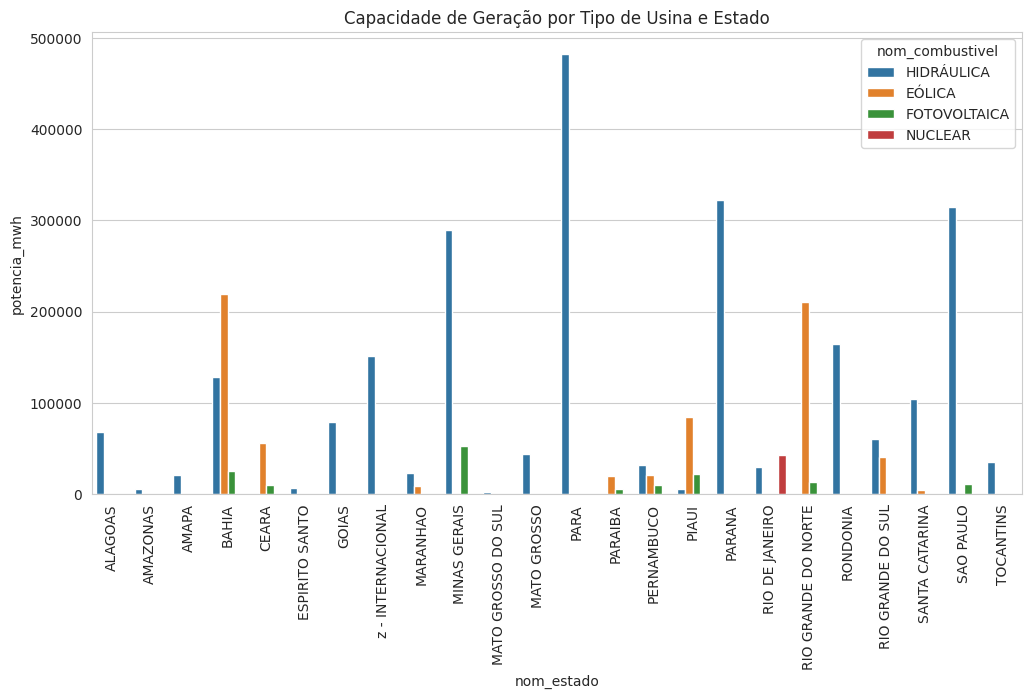

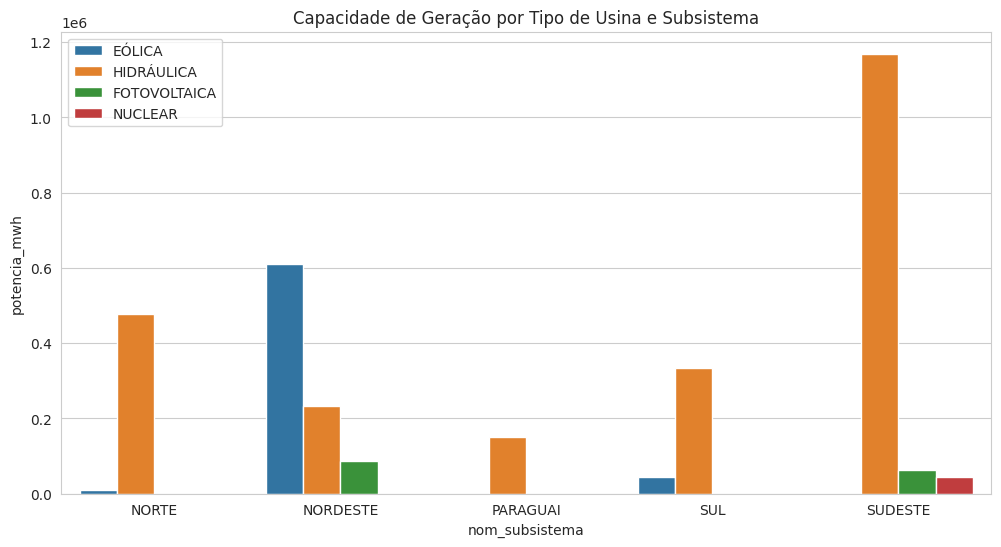

In [45]:
plt.figure(figsize=(12, 6))
plt.title('Capacidade de Geração por Tipo de Usina e Estado')
sns.barplot(
    data=df_capacidade_tipo_uf,
    x='nom_estado', y='potencia_mwh', hue='nom_combustivel',
    errorbar=None,

)
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12, 6))
plt.title('Capacidade de Geração por Tipo de Usina e Subsistema')
sns.barplot(
    data=df_capacidade_tipo_subsist,
    x='nom_subsistema', y='potencia_mwh', hue='nom_combustivel',
    errorbar=None,
)
plt.legend(loc='upper left')
plt.show()

In [46]:
top5_agentes = df_capacidade_tipo_agente.sort_values(
    'potencia_mwh', ascending=False
).groupby('nom_combustivel').head(5)

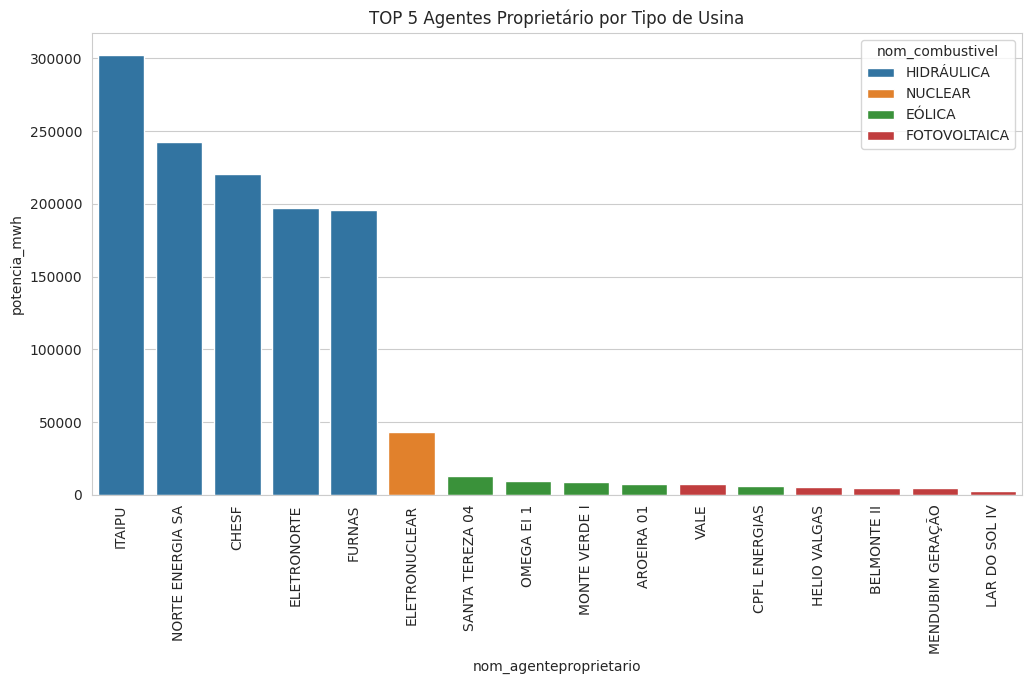

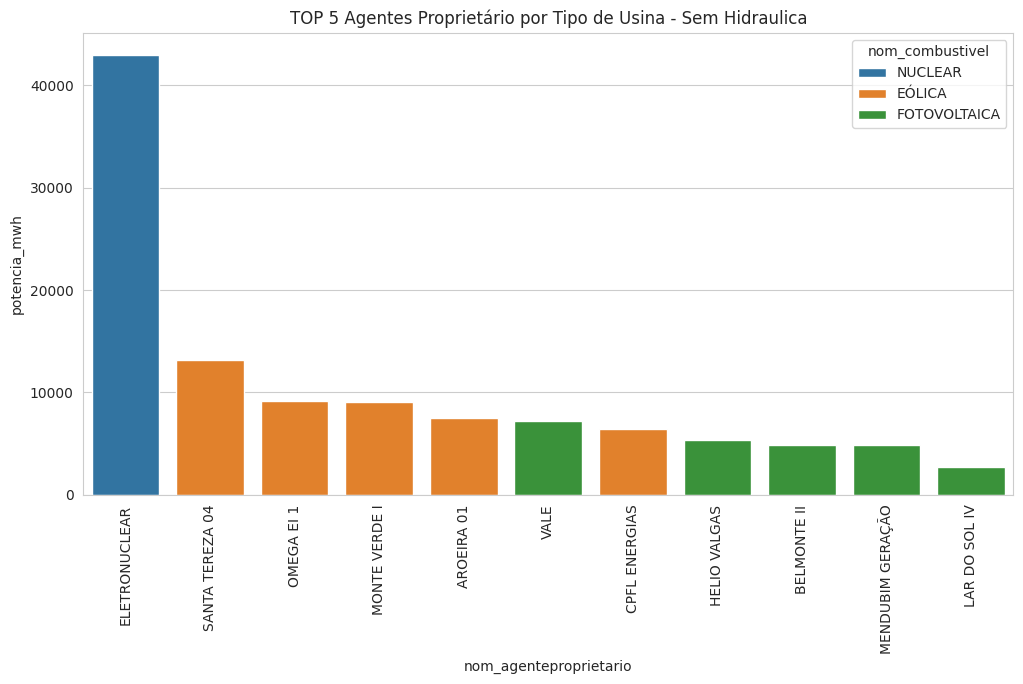

In [47]:
plt.figure(figsize=(12, 6))
plt.title('TOP 5 Agentes Proprietário por Tipo de Usina')
sns.barplot(
    data=top5_agentes,
    x='nom_agenteproprietario', y='potencia_mwh', hue='nom_combustivel',
    errorbar=None,
)
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12, 6))
plt.title('TOP 5 Agentes Proprietário por Tipo de Usina - Sem Hidraulica')
sns.barplot(
    data=top5_agentes[top5_agentes['nom_combustivel'] != 'HIDRÁULICA'],
    x='nom_agenteproprietario', y='potencia_mwh', hue='nom_combustivel',
    errorbar=None,
)
plt.xticks(rotation=90)
plt.show()

In [48]:
# Quantidade de agentes por tipo
df_capacidade_tipo_agente.groupby('nom_combustivel', as_index=False)['nom_agenteproprietario'].count()

,nom_combustivel,nom_agenteproprietario
0,EÓLICA,887
1,FOTOVOLTAICA,239
2,HIDRÁULICA,103
3,NUCLEAR,1


In [49]:
df_capacidade_usina.to_parquet('capacidade_usina.parquet')
df_capacidade_tipo_uf.to_parquet('capacidade_tipo_uf.parquet')
df_capacidade_tipo_subsist.to_parquet('capacidade_tipo_subsist.parquet')
df_capacidade_tipo_agente.to_parquet('capacidade_tipo_agente.parquet')

# Baixe os arquivos
files.download('capacidade_usina.parquet')
files.download('capacidade_tipo_uf.parquet')
files.download('capacidade_tipo_subsist.parquet')
files.download('capacidade_tipo_agente.parquet')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. **EPE**

In [50]:
import plotly.express as px
from datetime import datetime

from IPython.display import display

In [51]:
# Definição do caminho do arquivo
file_path = 'dados_abertos_consumo_mensal.xlsx'

# Obter todos os nomes das abas
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names  # Lista com os nomes de todas as abas

# Carregar todas as sheets do Excel em um dicionário de DataFrames
data = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheet_names}
sheet_names

['CONSUMO E NUMCONS SAM',
 'CONSUMO E NUMCONS SAM UF',
 'SETOR INDUSTRIAL POR RG',
 'ANALISE CONS NUMCONS SAM',
 'ANALISE CONS NUMCONS SAM UF',
 'ANALISE SETOR IND POR RG']

In [52]:
# Removendo as últimas 3 sheets
sheets_to_remove = ['ANALISE CONS NUMCONS SAM', 'ANALISE CONS NUMCONS SAM UF', 'ANALISE SETOR IND POR RG']
for sheet in sheets_to_remove:
    if sheet in data:
        del data[sheet]

# Verificando as sheets restantesa
print("Sheets restantes após remoção:")
print(data.keys())


Sheets restantes após remoção:
dict_keys(['CONSUMO E NUMCONS SAM', 'CONSUMO E NUMCONS SAM UF', 'SETOR INDUSTRIAL POR RG'])


In [53]:
# Verificando as primeiras linhas de cada sheet
for sheet in data:
    print(f"\nPrimeiras linhas da aba: {sheet}")
    display(data[sheet].head())



Primeiras linhas da aba: CONSUMO E NUMCONS SAM


,Data,DataExcel,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores
0,20240601,2024-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Cativo,448252.309,503876.0
1,20240601,2024-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Livre,200313.573,2075.0
2,20240601,2024-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Cativo,81441.302,31757.0
3,20240601,2024-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,884213.886,899.0
4,20240601,2024-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Outros,Cativo,359051.301,63248.0



Primeiras linhas da aba: CONSUMO E NUMCONS SAM UF


,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores
0,20240501,2024-05-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,4128.750,3763.0
1,20240501,2024-05-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,374.860,34.0
2,20240501,2024-05-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,3955.410,1127.0
3,20240501,2024-05-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,9141.647,46242.0
4,20240501,2024-05-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1525.260,2698.0



Primeiras linhas da aba: SETOR INDUSTRIAL POR RG


,Data,DataExcel,SetorIndustrial,Regiao,Consumo
0,20240601,2024-06-01,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Centro-Oeste,69427.966
1,20240601,2024-06-01,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Nordeste,118975.099
2,20240601,2024-06-01,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Norte,308928.586
3,20240601,2024-06-01,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Sudeste,692765.640
4,20240601,2024-06-01,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Sul,781.616


In [54]:
# Exibindo os tipos de dados e estatísticas descritivas para cada aba
for sheet in data:
    print(f"\nTipos de dados da aba: {sheet}")
    print(display(data[sheet].dtypes))

    print(f"\nEstatísticas descritivas da aba: {sheet}")
    print(display(data[sheet].describe(include='all')))


Tipos de dados da aba: CONSUMO E NUMCONS SAM


,0
Data,int64
DataExcel,datetime64[ns]
Regiao,object
Sistema,object
Classe,object
TipoConsumidor,object
Consumo,float64
Consumidores,float64


None

Estatísticas descritivas da aba: CONSUMO E NUMCONS SAM


,Data,DataExcel,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores
count,1.666100e+04,16661,16661,16661,16661,16661,1.666100e+04,1.666100e+04
unique,NaN,NaN,5,5,5,2,NaN,NaN
top,NaN,NaN,Nordeste,SUDESTE / CENTRO - OESTE,Industrial,Cativo,NaN,NaN
freq,NaN,NaN,4924,5349,4030,11840,NaN,NaN
mean,2.014491e+07,2014-11-17 08:01:19.515034880,NaN,NaN,NaN,NaN,5.445647e+05,1.095460e+06
min,2.004010e+07,2004-01-01 00:00:00,NaN,NaN,NaN,NaN,-2.210000e+02,0.000000e+00
25%,2.010020e+07,2010-02-01 00:00:00,NaN,NaN,NaN,NaN,1.223841e+04,1.190000e+02
50%,2.015040e+07,2015-04-01 00:00:00,NaN,NaN,NaN,NaN,1.233527e+05,1.579200e+04
75%,2.019120e+07,2019-12-01 00:00:00,NaN,NaN,NaN,NaN,5.764050e+05,2.473580e+05
max,2.024060e+07,2024-06-01 00:00:00,NaN,NaN,NaN,NaN,7.903367e+06,3.646215e+07


None

Tipos de dados da aba: CONSUMO E NUMCONS SAM UF


...

None

Tipos de dados da aba: SETOR INDUSTRIAL POR RG


,0
Data,int64
DataExcel,datetime64[ns]
SetorIndustrial,object
Regiao,object
Consumo,float64


None

Estatísticas descritivas da aba: SETOR INDUSTRIAL POR RG


,Data,DataExcel,SetorIndustrial,Regiao,Consumo
count,7.500000e+03,7500,7500,7500,7.500000e+03
unique,NaN,NaN,10,5,NaN
top,NaN,NaN,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,Centro-Oeste,NaN
freq,NaN,NaN,750,1500,NaN
mean,2.017824e+07,2018-03-17 06:33:36,NaN,NaN,2.387809e+05
min,2.012010e+07,2012-01-01 00:00:00,NaN,NaN,2.066700e+01
25%,2.015020e+07,2015-02-01 00:00:00,NaN,NaN,1.959300e+04
50%,2.018035e+07,2018-03-16 12:00:00,NaN,NaN,1.340368e+05
75%,2.021050e+07,2021-05-01 00:00:00,NaN,NaN,2.985190e+05
max,2.024060e+07,2024-06-01 00:00:00,NaN,NaN,2.483892e+06


None


In [55]:
# Tratamento de valores faltantes e inconsistentes
for sheet in data:
    print(f"\nValores faltantes na aba: {sheet}")

    # Contagem total de valores faltantes
    missing_total = data[sheet].isnull().sum().sum()
    print(f"Total de valores faltantes: {missing_total}")

    # Exibe também a contagem de valores faltantes por coluna
    missing_count = data[sheet].isnull().sum()
    print("Contagem de valores faltantes por coluna:")
    print(missing_count)

    # Após verificar, preenche valores faltantes (estratégia simples)
    for column in data[sheet].columns:
        if data[sheet][column].dtype == 'object':
            # Preencher valores categóricos com o valor mais comum (moda)
            data[sheet][column].fillna(data[sheet][column].mode()[0], inplace=True)
        else:
            # Preencher valores numéricos com a média
            data[sheet][column].fillna(data[sheet][column].mean(), inplace=True)



Valores faltantes na aba: CONSUMO E NUMCONS SAM
Total de valores faltantes: 0
Contagem de valores faltantes por coluna:
Data              0
DataExcel         0
Regiao            0
Sistema           0
Classe            0
TipoConsumidor    0
Consumo           0
Consumidores      0
dtype: int64

Valores faltantes na aba: CONSUMO E NUMCONS SAM UF
Total de valores faltantes: 0
Contagem de valores faltantes por coluna:
Data              0
DataExcel         0
UF                0
Regiao            0
Sistema           0
Classe            0
TipoConsumidor    0
Consumo           0
Consumidores      0
dtype: int64

Valores faltantes na aba: SETOR INDUSTRIAL POR RG
Total de valores faltantes: 0
Contagem de valores faltantes por coluna:
Data               0
DataExcel          0
SetorIndustrial    0
Regiao             0
Consumo            0
dtype: int64


<ipython-input-55-8437eb56b2a6>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[sheet][column].fillna(data[sheet][column].mean(), inplace=True)
<ipython-input-55-8437eb56b2a6>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

| Campo          | Tipo              | Descrição                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|----------------|-------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data           | Data<br>AAAAMMDD  | Data de registro do dado, contém o mês e o ano em que<br>ocorreu o consumo; ou: data do registro do dado, contém o<br>mês e o ano da aferição do número de<br>unidades consumidoras                                                                                                                                                                                                                                                                                                                                                                                      |
| DataExcel      | Número<br>Inteiro | Formato de data do MS Excel. O Excel armazena datas como<br>números de série sequenciais para que possam ser usados em<br>cálculos, onde 1 de janeiro de 1900 é o número de série 1.                                                                                                                                                                                                                                                                                                                                                                                     |
| Regiao         | Texto             | Região Geográfica do Brasil:<br>• Centro-Oeste<br>• Nordeste<br>• Norte<br>• Sudeste<br>• Sul                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| Sistema        | Texto             | Subsistema ou Sistemas Isolados<br>Subsistema: Divisões do SIN para as quais são estabelecidos<br>PLDs específicos e cujas fronteiras são definidas em razão da<br>presença e duração de restrições relevantes de transmissão<br>aos fluxos de energia elétrica no SIN. Resolução Normativa<br>Aneel n. 109, de 26 de outubro de 2004.<br>Sistemas Isolados: Sistemas elétricos radiais (geração<br>dedicada a um mercado específico), não interconectados ao<br>SIN. Em sua quase totalidade estão situados na Região Norte<br>do País e atendidos por geração térmica. |
| Classe         | Texto             | Classe de Consumo:<br>• Residencial<br>• Industrial<br>• Comercial<br>• Rural<br>• Outros                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| TipoConsumidor | Texto             | Tipo de Consumidor<br>Cativo ou Livre                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Consumo        | Número            | Consumo em MWh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Consumidores   | Número            | Número de Unidades Consumidoras:<br>Conjunto de instalações e equipamentos elétricos<br>caracterizado pelo recebimento de energia elétrica em um só<br>ponto de entrega, com medição individualizada e<br>correspondente a um único consumidor. Resolução Aneel n.<br>083, de 20 de setembro de 2004.                                                                                                                                                                                                                                                                    |


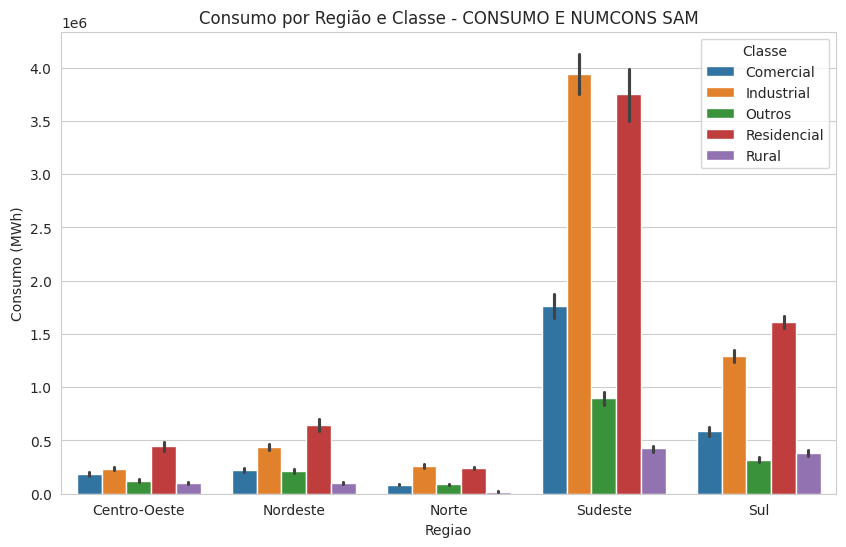

In [56]:
# Distribuição do consumo por região e classe
plt.figure(figsize=(10,6))
sns.barplot(x='Regiao', y='Consumo', hue='Classe', data=data['CONSUMO E NUMCONS SAM'])
plt.title('Consumo por Região e Classe - CONSUMO E NUMCONS SAM')
plt.ylabel('Consumo (MWh)')
plt.show()

*texto em itálico*## **Distribuição de Consumo por Região e Classe**:

- **Análise**: Ao visualizar o gráfico de barras do consumo por **região** e **classe**, é possível identificar quais regiões possuem os maiores consumidores de energia elétrica e se existe uma classe que consome mais em cada região.

**Exemplo de Insight**:

- **Regiões metropolitanas** podem apresentar um consumo elevado em classes **residenciais** e **comerciais**, enquanto regiões mais industriais podem ter um consumo maior na **classe industrial**.
- Se observarmos que a classe **residencial** tem o maior consumo em várias regiões, isso pode sugerir um crescimento populacional elevado ou uma maior dependência de eletricidade nas atividades diárias.

**Ação**: As concessionárias podem priorizar políticas de eficiência energética nessas regiões para mitigar o consumo em horários de pico.


| Campo          | Tipo              | Descrição                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|----------------|-------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data           | Data<br>AAAAMMDD  | Data de registro do dado, contém o mês e o ano em que<br>ocorreu o consumo; ou: data do registro do dado, contém o<br>mês e o ano da aferição do número de<br>unidades consumidoras                                                                                                                                                                                                                                                                                                                                                                                      |
| DataExcel      | Número<br>Inteiro | Formato de data do MS Excel. O Excel armazena datas como<br>números de série sequenciais para que possam ser usados em<br>cálculos, onde 1 de janeiro de 1900 é o número de série 1.                                                                                                                                                                                                                                                                                                                                                                                     |
| UF             | Texto             | Unidade da Federação                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| Regiao         | Texto             | Região Geográfica do Brasil:<br>• Centro-Oeste<br>• Nordeste<br>• Norte<br>• Sudeste<br>• Sul                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| Sistema        | Texto             | Subsistema ou Sistemas Isolados<br>Subsistema: Divisões do SIN para as quais são estabelecidos<br>PLDs específicos e cujas fronteiras são definidas em razão da<br>presença e duração de restrições relevantes de transmissão<br>aos fluxos de energia elétrica no SIN. Resolução Normativa<br>Aneel n. 109, de 26 de outubro de 2004.<br>Sistemas Isolados: Sistemas elétricos radiais (geração<br>dedicada a um mercado específico), não interconectados ao<br>SIN. Em sua quase totalidade estão situados na Região Norte<br>do País e atendidos por geração térmica. |
| Classe         | Texto             | Classe de Consumo:<br>• Residencial<br>• Industrial<br>• Comercial<br>• Rural<br>• Outros                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| TipoConsumidor | Texto             | Tipo de Consumidor<br>Cativo ou Livre                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Consumo        | Número            | Consumo em MWh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Consumidores   | Número            | Número de Unidades Consumidoras:<br>Conjunto de instalações e equipamentos elétricos<br>caracterizado pelo recebimento de energia elétrica em um só<br>ponto de entrega, com medição individualizada e<br>correspondente a um único consumidor. Resolução Aneel n.<br>083, de 20 de setembro de 2004.                                                                                                                                                                                                                                                                    |


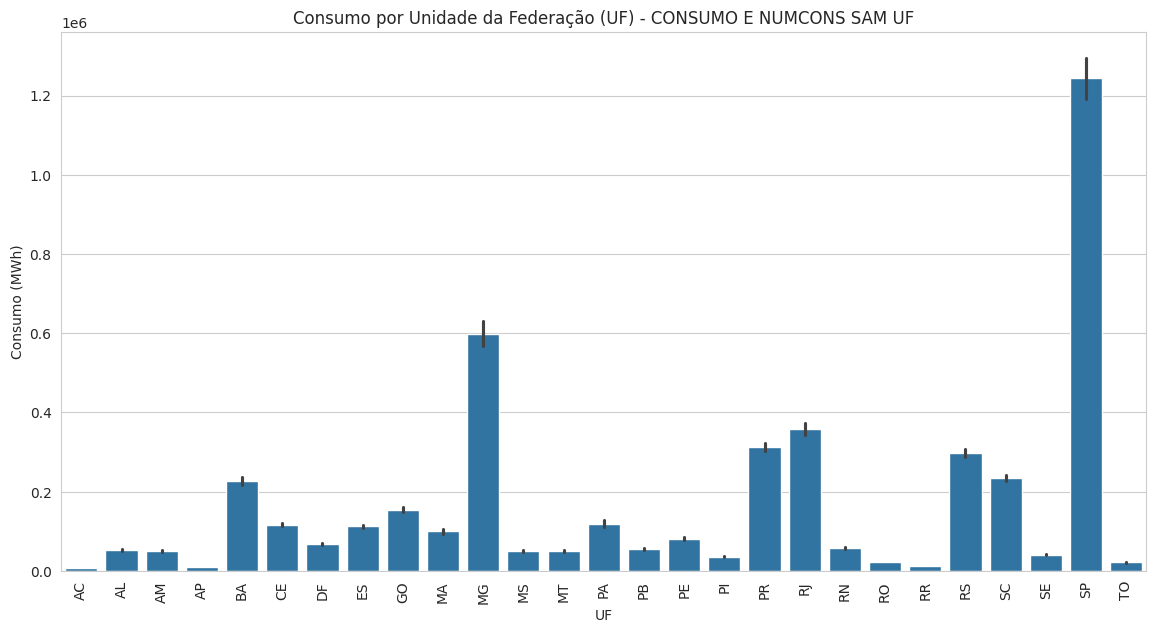

In [57]:
# Comparação de consumo por Unidade da Federação (UF)
plt.figure(figsize=(14,7))
sns.barplot(x='UF', y='Consumo', data=data['CONSUMO E NUMCONS SAM UF'])
plt.title('Consumo por Unidade da Federação (UF) - CONSUMO E NUMCONS SAM UF')
plt.ylabel('Consumo (MWh)')
plt.xticks(rotation=90)
plt.show()


### **Consumo por Unidade da Federação (UF)**:

- **Análise**: Gráficos que comparam o consumo entre diferentes **Unidades da Federação (UF)** podem revelar quais estados consomem mais energia, e podem estar relacionados com características locais, como o desenvolvimento industrial ou densidade populacional.

**Exemplo de Insight**:

- Se o estado de **São Paulo** é responsável pelo maior consumo, isso pode ser reflexo do grande número de indústrias e da população elevada.
- Estados com menor consumo de energia podem indicar infraestrutura elétrica menos desenvolvida ou menor presença de atividades industriais.

**Ação**: Investimentos podem ser direcionados a estados com menor consumo para melhorar a infraestrutura elétrica, enquanto estados de alto consumo podem adotar políticas de incentivo à eficiência energética.


| Campo           | Tipo              | Descrição                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
|-----------------|-------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Data            | Data<br>AAAAMMDD  | Data de registro do dado, contém o mês e o ano em que<br>ocorreu o consumo; ou: data do registro do dado, contém o<br>mês e o ano da aferição do número de<br>unidades consumidoras                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| DataExcel       | Número<br>Inteiro | Formato de data do MS Excel. O Excel armazena datas como<br>números de série sequenciais para que possam ser usados em<br>cálculos, onde 1 de janeiro de 1900 é o número de série 1.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| SetorIndustrial | Texto             | O setor industrial referente a tabela CNAE 2.0 do IBGE. São<br>disponibilizados consumo dos setores industriais 10+<br>eletrointensivos:<br>• 07 - EXTRAÇÃO DE MINERAIS METÁLICOS<br>• 10 - FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS<br>• 13 - FABRICAÇÃO DE PRODUTOS TÊXTEIS<br>• 17 - FABRICAÇÃO DE CELULOSE, PAPEL E PRODUTOS DE<br>PAPEL<br>• 20 - FABRICAÇÃO DE PRODUTOS QUÍMICOS<br>• 22 - FABRICAÇÃO DE PRODUTOS DE BORRACHA E DE<br>MATERIAL PLÁSTICO<br>• 23 - FABRICAÇÃO DE PRODUTOS DE MINERAIS NÃOMETÁLICOS<br>• 24 - METALURGIA<br>• 25 - FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO<br>MÁQUINAS E EQUIPAMENTOS<br>• 29 - FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES<br>E CARROCERIAS |
| Regiao          | Texto             | Região Geográfica do Brasil:<br>• Centro-Oeste<br>• Nordeste<br>• Norte<br>• Sudeste<br>• Sul                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Consumo         | Número            | Consumo em MWh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |


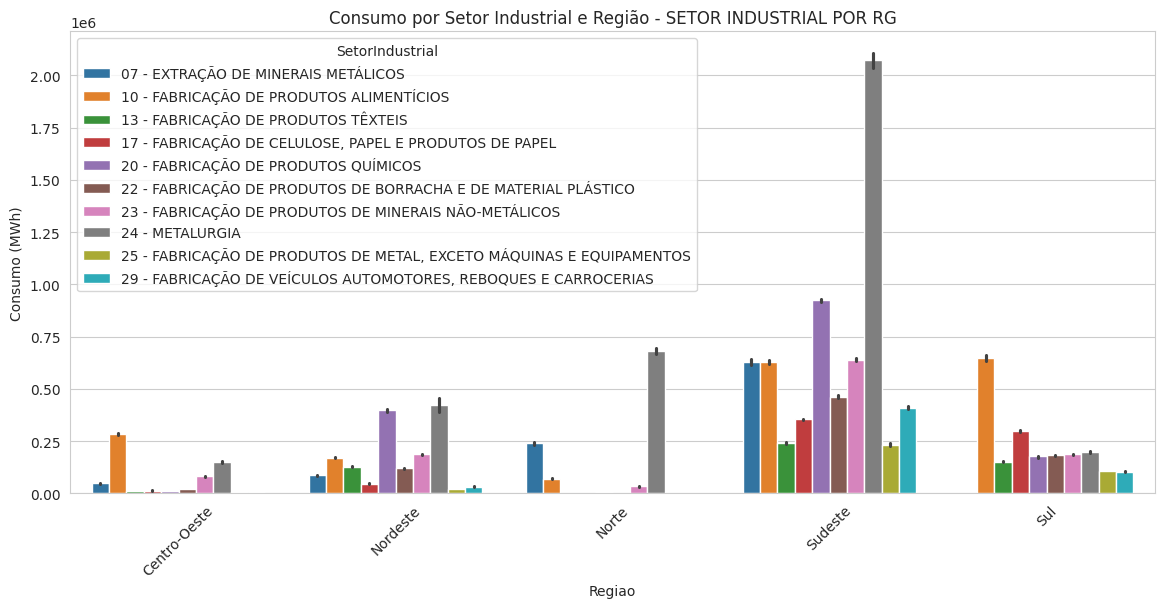

In [58]:
# Consumo dos setores industriais por região
if 'SETOR INDUSTRIAL POR RG' in data:
    plt.figure(figsize=(14,6))
    sns.barplot(x='Regiao', y='Consumo', hue='SetorIndustrial', data=data['SETOR INDUSTRIAL POR RG'])
    plt.title('Consumo por Setor Industrial e Região - SETOR INDUSTRIAL POR RG')
    plt.ylabel('Consumo (MWh)')
    plt.xticks(rotation=45)
    plt.show()

### **Consumo por Setor Industrial e Região**:

- **Análise**: Ao observar o consumo de energia elétrica dividido por **setores industriais** e **regiões**, é possível identificar quais setores da economia estão demandando mais energia em diferentes partes do país.

**Exemplo de Insight**:

- Se o setor **metalúrgico** ou **químico** apresenta um consumo elevado em uma região específica, isso pode sugerir a presença de grandes polos industriais nessas áreas.
- A **indústria de alimentos** pode ter maior consumo em regiões agrícolas ou produtoras, enquanto setores como o **têxtil** podem estar concentrados em áreas com mão de obra intensiva.

**Ação**: A alocação de energia e planejamento de infraestrutura pode ser direcionado para apoiar esses setores e minimizar o risco de sobrecarga.

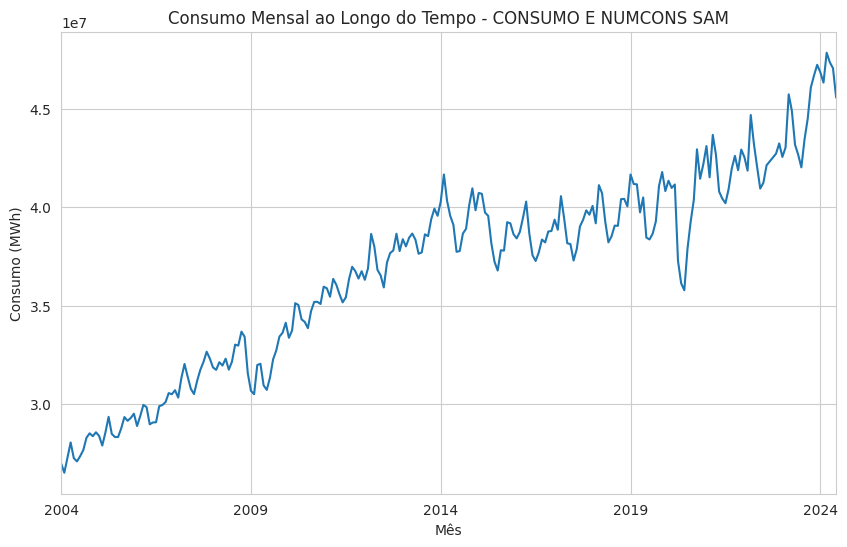

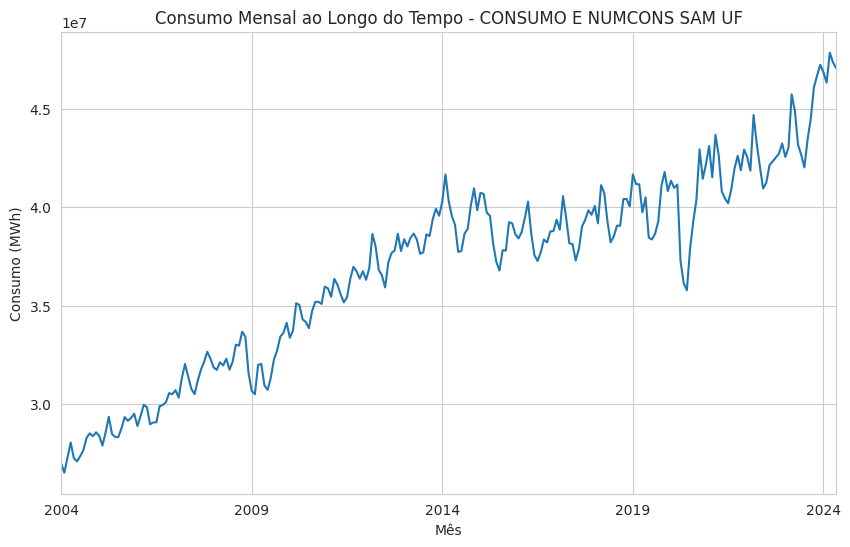

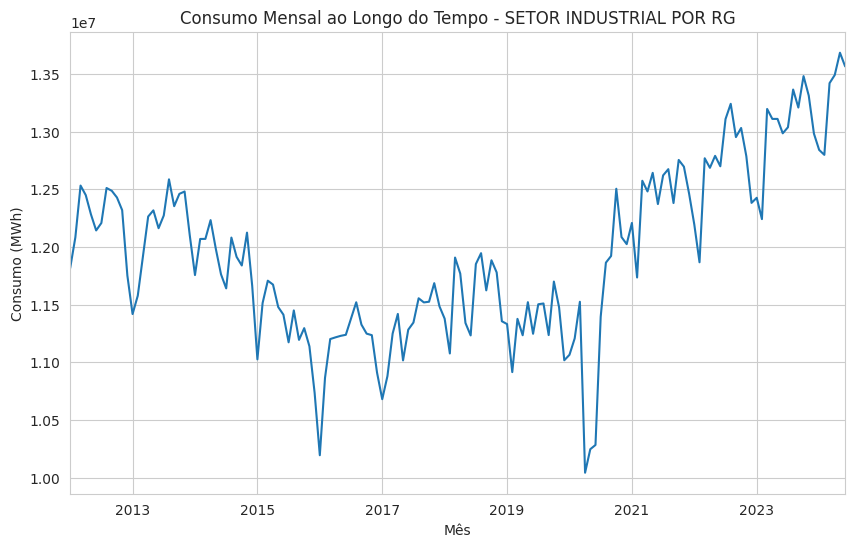

In [59]:
# Análise Temporal (se houver colunas de data)
for sheet in data:
    if 'Data' in data[sheet].columns and 'Consumo' in data[sheet].columns:
        # Garantindo que a coluna 'Data' seja string antes da conversão
        data[sheet]['Data'] = data[sheet]['Data'].astype(str)

        # Convertendo a coluna de data que está no formato AAAAMMDD para datetime
        data[sheet]['Data'] = pd.to_datetime(data[sheet]['Data'], format='%Y%m%d', errors='coerce')

        # Removendo valores onde a conversão falhou
        data[sheet].dropna(subset=['Data'], inplace=True)

        # Verificar se a coluna 'Consumo' tem valores válidos
        if data[sheet]['Consumo'].isnull().all():
            print(f"Aba {sheet}: Nenhum valor válido na coluna 'Consumo'. Pulando análise temporal.")
            continue

        # Agrupando por mês e somando os valores de consumo
        consumo_mensal = data[sheet].groupby(data[sheet]['Data'].dt.to_period('M'))['Consumo'].sum()

        # Verificando se o agrupamento gerou resultados
        if consumo_mensal.empty:
            print(f"Aba {sheet}: Nenhum dado disponível após o agrupamento. Pulando plotagem.")
            continue

        # Plotando o consumo mensal
        plt.figure(figsize=(10,6))
        consumo_mensal.plot()
        plt.title(f'Consumo Mensal ao Longo do Tempo - {sheet}')
        plt.ylabel('Consumo (MWh)')
        plt.xlabel('Mês')
        plt.show()


### **Análise Temporal**:

- **Análise**: Analisando o consumo ao longo do tempo, você pode identificar **tendências sazonais** ou **picos de consumo** relacionados a épocas do ano.

**Exemplo de Insight**:

- Um aumento no consumo durante o verão pode estar relacionado ao uso mais frequente de **ar-condicionado** ou **ventiladores**, enquanto picos no inverno podem refletir o uso de **aquecedores elétricos**.
- O comportamento do consumo ao longo do tempo pode sugerir a necessidade de programas de gerenciamento de demanda para evitar sobrecarga nas redes elétricas em certos períodos.


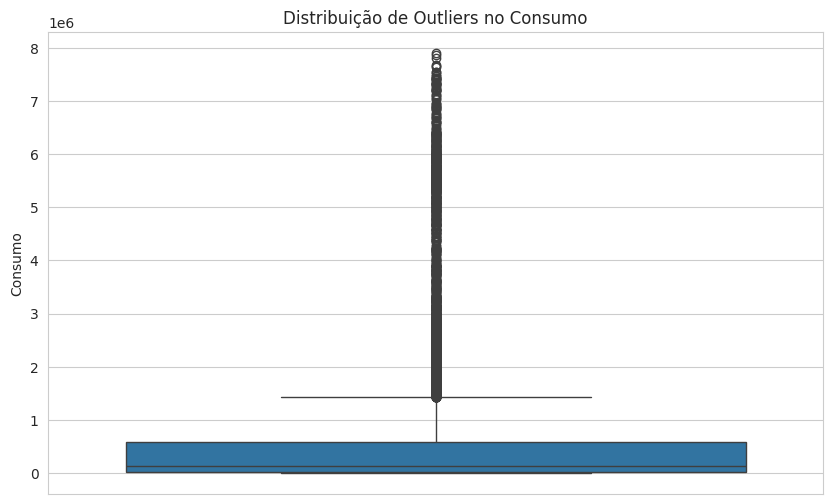

In [60]:
# Verificando outliers com boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data['CONSUMO E NUMCONS SAM']['Consumo'])
plt.title("Distribuição de Outliers no Consumo")
plt.show()

# Se necessário, remover outliers
Q1 = data['CONSUMO E NUMCONS SAM']['Consumo'].quantile(0.25)
Q3 = data['CONSUMO E NUMCONS SAM']['Consumo'].quantile(0.75)
IQR = Q3 - Q1
outliers_removed = data['CONSUMO E NUMCONS SAM'][
    ~((data['CONSUMO E NUMCONS SAM']['Consumo'] < (Q1 - 1.5 * IQR)) |
      (data['CONSUMO E NUMCONS SAM']['Consumo'] > (Q3 + 1.5 * IQR)))
]

In [61]:
# Códigos aqui

# **Modelo base**

Aplicação de, pelo menos, um primeiro modelo (modelo de aprendizado de máquina ou modelo estatístico) que deve ser refinado até a entrega final do projeto. Apresente o método aplicado e a análise dos resultados obtidos.

# **Cronograma**

Atualizar o cronograma, se necessário, das atividades.

# **Referências**

Complementar a entrega anterior.




In [ ]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

Revisao = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao_geral = 10 #@param {type:"slider", min:0, max:10, step:1}








In [ ]:
#@title **Nota Final**
nota = 0.4*EDA_e_preprocessamento + 0.2*Modelo_base + 0.2*Revisao + 0.2*Apresentacao_geral

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
